In [1]:
import tenpy

## image time TEBD

- generate tenpy model by `tenpy_tebd_model`

- set image-time TEBD parameters by `tenpy_tebd_params_image_time`

- run TEBD by `tenpy_tebd_GS_`

In [4]:
import quante as qt
import numpy as np
from quante.generate.tenpy_bridge.tebd import tenpy_tebd_model, tenpy_tebd_GS_, tenpy_tebd_params_imag_time
import tenpy

g = 1.0
op = qt.generate.operas.spin
L = 10
ham = - op.sum(op.xx(i, i+1) for i in range(L-1)) - g * op.sum(op.z(i) for i in range(L))
M = tenpy_tebd_model(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='finite',
)
tebd_params = tenpy_tebd_params_imag_time(
        delta_tau_list=[0.1, 0.01, 0.001, 1.e-4, 1.e-5],
        order=2,
        N_steps=10,
        chi_max=30,
        svd_min=1.e-10,
        max_error_E=1.e-6,
    )
product_state = ["up"] * M.lat.N_sites
psi = tenpy.networks.MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)
tenpy_tebd_GS_(psi, M, tebd_params)
E = np.sum(M.bond_energies(psi))  # M.bond_energies() works only a for NearestNeighborModel
print("E = {E:.13f}".format(E=E))
E_exact = qt.generate.operas.heisenberg_operator(L=L, j=(-1,0,0), h=-1.0).gdenergy(pauli=True)
print("Analytic result: E (per site) = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))

E = -12.3814873808738
Analytic result: E (per site) = -12.3814899996548
relative error:  2.1150773788174456e-07


the inifinite chain can be simulated by setting `bc_MPS` to `infinite` in the model.

and `L = 2` in the operator.


In [5]:
import quante as qt
import numpy as np
from quante.generate.tenpy_bridge.tebd import tenpy_tebd_model, tenpy_tebd_GS_, tenpy_tebd_params_imag_time
import tenpy

g = 1.0
op = qt.generate.operas.spin
L = 2
ham = - op.sum(op.xx(i, i+1) for i in range(L)) - g * op.sum(op.z(i) for i in range(L))
M = tenpy_tebd_model(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='infinite',
)
L = np.inf
tebd_params = tenpy_tebd_params_imag_time(
        delta_tau_list=[0.1, 0.01, 0.001, 1.e-4, 1.e-5],
        order=2,
        N_steps=10,
        chi_max=30,
        svd_min=1.e-10,
        max_error_E=1.e-6,
    )
product_state = ["up"] * M.lat.N_sites
psi = tenpy.networks.MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)
tenpy_tebd_GS_(psi, M, tebd_params)
E = np.mean(M.bond_energies(psi))  # M.bond_energies() works only a for NearestNeighborModel
print("E = {E:.13f}".format(E=E))
E_exact = qt.generate.operas.heisenberg_operator(L=L, j=(-1,0,0), h=-1.0).gdenergy(pauli=True)
print("Analytic result: E (per site) = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))

E = -1.2732308289914
Analytic result: E (per site) = -1.2732395447352
relative error:  6.845329140736557e-06


## real time TEBD

use `tenpy_tebd_` to run real time TEBD.

one can also use `tenpy.algorithms.tebd.TEBDEngine(psi, M, tebd_params)` directly to run TEBD.

the parameters can be set by `tenpy_tebd_params_real_time`.

100%|##########| 100/100 [00:03<00:00, 29.05it/s]


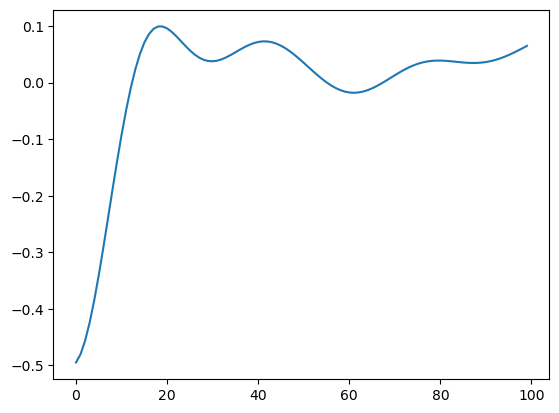

In [34]:
import quante as qt
from quante.generate.tenpy_bridge.tebd import (
    tenpy_tebd_model, tenpy_tebd_params_real_time, tenpy_tebd_
)
import tenpy
op = qt.generate.operas.spin

L = 12
ham = op.heisenberg_operator(L)
M = tenpy_tebd_model(
    L=L, oper=ham, pauli=False, conserve='Sz', bc_MPS='finite',
)

psi = tenpy.networks.MPS.from_product_state(
    M.lat.mps_sites(), ["up", "down"]*(L//2)
)

tebd_params = tenpy_tebd_params_real_time(
    dt=0.1,
    N_steps=1,
    order=2,
    chi_max=50,
    svd_min=1.e-10,
    trunc_cut=None,
)

res = []
for t, psi in tenpy_tebd_(psi, M, 10, tebd_params, progressbar=True):
    res.append(psi.expectation_value('Sz', 3)[0])

import matplotlib.pyplot as plt
plt.plot(res)

## Finite DMRG

to run finite DMRG, we need

- generate tenpy model by `tenpy_mpo_model`

- set DMRG parameters by `tenpy_dmrg_params`

- run DMRG by `tenpy_dmrg`

In [ ]:
import quante as qt
import numpy as np
from quante.generate.tenpy_bridge.dmrg import (
    tenpy_mpo_model, tenpy_dmrg_params, tenpy_dmrg
)
from tenpy.networks.mps import MPS

L = 10
g = 1.0
op = qt.generate.operas.spin
ham = - op.sum(op.xx(i, i+1) for i in range(L-1)) - g * op.sum(op.z(i) for i in range(L)) + op.xx(1,3)
M = tenpy_mpo_model(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='finite',
)

product_state = ["up"] * M.lat.N_sites
psi = MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)

dmrg_params = tenpy_dmrg_params(
    active_sites=2,
    chi_max=30,
    svd_min=1.e-10,
)

E, _, _ = tenpy_dmrg(psi, M, dmrg_params)  # the main work...

print("E = {E:.13f}".format(E=E))
print("final bond dimensions: ", psi.chi)
mag_x = np.sum(psi.expectation_value("Sigmax"))
mag_z = np.sum(psi.expectation_value("Sigmaz"))
print("magnetization in X = {mag_x:.5f}".format(mag_x=mag_x))
print("magnetization in Z = {mag_z:.5f}".format(mag_z=mag_z))
E_exact = ham.gdenergy(pauli=True)
print("Exact diagonalization: E = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))


E = -12.3131598724129
final bond dimensions:  [2, 4, 8, 16, 18, 14, 8, 4, 2]
magnetization in X = 0.00000
magnetization in Z = 7.72189
Exact diagonalization: E = -12.3131598724129
relative error:  1.5869139551400653e-15


## inFinite DMRG

set `bc_MPS` to `infinite` in the model.

In [2]:
import quante as qt
import numpy as np
from quante.generate.tenpy_bridge.dmrg import (
    tenpy_mpo_model, tenpy_dmrg_params, tenpy_dmrg
)
from tenpy.networks.mps import MPS

op = qt.generate.operas.spin
L = 2
g = 1.5
ham = - op.sum(op.xx(i, i+1) for i in range(L)) - g * op.sum(op.z(i) for i in range(L))
M = tenpy_mpo_model(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='infinite',
)

product_state = ["up"] * M.lat.N_sites
psi = MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)

dmrg_params = tenpy_dmrg_params(
    mixer=True,
    chi_max=30,
    svd_min=1.e-10,
    max_E_err=1.e-10,
)
E, psi, _ = tenpy_dmrg(psi, M, dmrg_params)  # the main work...

print("E = {E:.13f}".format(E=E))
print("final bond dimensions: ", psi.chi)
mag_x = np.mean(psi.expectation_value("Sigmax"))
mag_z = np.mean(psi.expectation_value("Sigmaz"))
print("<sigma_x> = {mag_x:.5f}".format(mag_x=mag_x))
print("<sigma_z> = {mag_z:.5f}".format(mag_z=mag_z))
print("correlation length:", psi.correlation_length())
E_exact = qt.generate.operas.spin.heisenberg_operator(L=np.inf, j=(-1.,0,0), h=(0,0,-g)).gdenergy(pauli=True)
print("Analytic result: E(per site) = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))


E = -1.6719262215361
final bond dimensions:  [21, 21]
<sigma_x> = -0.00000
<sigma_z> = 0.87733
correlation length: 2.4113432996820197
Analytic result: E(per site) = -1.6719262215362
relative error:  4.170160444185033e-14


## tenpy logging

the tenpy output can be set by `set_tenpy_logging`.

This will also change the logger!

In [4]:
import quante as qt
import numpy as np
from quante.generate.tenpy_bridge.dmrg import (
    tenpy_mpo_model, tenpy_dmrg_params, tenpy_dmrg
)
from quante.generate.tenpy_bridge import set_tenpy_logging
from tenpy.networks.mps import MPS

set_tenpy_logging(level=1)

op = qt.generate.operas.spin
L = 2
g = 1.5
ham = - op.sum(op.xx(i, i+1) for i in range(L)) - g * op.sum(op.z(i) for i in range(L))
M = tenpy_mpo_model(
    L=L, oper=ham, pauli=True, conserve='None', bc_MPS='infinite',
)

product_state = ["up"] * M.lat.N_sites
psi = MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)

dmrg_params = tenpy_dmrg_params(
    mixer=True,
    chi_max=30,
    svd_min=1.e-10,
    max_E_err=1.e-10,
)
E, psi, _ = tenpy_dmrg(psi, M, dmrg_params)  # the main work...

print("E = {E:.13f}".format(E=E))
print("final bond dimensions: ", psi.chi)
mag_x = np.mean(psi.expectation_value("Sigmax"))
mag_z = np.mean(psi.expectation_value("Sigmaz"))
print("<sigma_x> = {mag_x:.5f}".format(mag_x=mag_x))
print("<sigma_z> = {mag_z:.5f}".format(mag_z=mag_z))
print("correlation length:", psi.correlation_length())
E_exact = qt.generate.operas.spin.heisenberg_operator(L=np.inf, j=(-1.,0,0), h=(0,0,-g)).gdenergy(pauli=True)
print("Analytic result: E(per site) = {E:.13f}".format(E=E_exact))
print("relative error: ", abs((E - E_exact) / E_exact))


TenpyMPOModel: reading 'bc_MPS'='infinite'
TenpyMPOModel: reading 'conserve'='None'
TenpyMPOModel: reading 'L'=2
TenpyMPOModel: reading 'oper'=<quante.generate.operas.spin.SpinOper object at 0x000002ACFBC77A40>
TenpyMPOModel: reading 'pauli'=True
DMRG: reading 'active_sites'=2
DMRG: reading 'diag_method'='default'
DMRG: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
DMRG: subconfig 'lanczos_params'=Config(<0 options>, 'lanczos_params')
DMRG: reading 'chi_list'=None
start environment_sweep
trunc_params: reading 'chi_max'=30
trunc_params: reading 'svd_min'=1e-10
DMRG: subconfig 'mixer_params'=Config(<0 options>, 'mixer_params')
DMRG: reading 'mixer'=True
activate DensityMatrixMixer with initial amplitude 1e-05
Running sweep with optimization
start environment_sweep
checkpoint after sweep 10
energy=-1.6719262215362427, max S=0.1534954327561873, age=128, norm_err=9.1e-14
Current memory usage 175.2MB, wall time: 0.6s
Delta E = nan, Delta S = 1.5350e-02 (per sweep)
max trunc_er

E = -1.6719262215361
final bond dimensions:  [21, 21]
<sigma_x> = -0.00000
<sigma_z> = 0.87733
correlation length: 2.411343299682044
Analytic result: E(per site) = -1.6719262215362
relative error:  4.170160444185033e-14
